# Stereo-seq E12.5 Mouse Embryo Dataset

### Gene set activity quantification and spatial GAS gradient analysis

GESSO (Gene sEt activity Score analysis with Spatial lOcation) is a computational method for quantifying the overall expression levels of gene sets for spatial transcriptomics data. Given spatial transcriptomics data and a user-provided gene set, GESSO returns a gene set activity score (GAS) for each spot. The `lowres` compute method makes GESSO scalable to high-resolution platforms with tens of thousands of spots.

This notebook demonstrates GESSO on the Stereo-seq mouse embryo dataset at embryonic day 12.5 (E12.5) (Chen et al., *Cell*, 2022), which contains ~51,000 spots. We score the curated panel of organ-system-specific gene sets, visualize spatial maps for representative organ systems, and compute local spatial gradients of the activity scores to highlight tissue boundaries.

All paths below point to the original locations of the data on the OSCAR compute system; replace them with your own when re-running.

### Import the `gesso` package

The `gesso` Python package can be easily downloaded from source. Simply run the following script in your terminal after ensuring Python and pip are available in your environment. We recommend installing GESSO in a new Python environment.

```bash
git clone https://github.com/YMa-Lab/GESSO.git
cd GESSO
pip install .
cd ..
```

Reading Stereo-seq `.Rds` files additionally requires `pyreadr`:

```bash
pip install pyreadr
```

In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import pyreadr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree

project_directory = Path("__notebook__").resolve().parent.parent
sys.path.append(str(project_directory))

from gesso import GESSO

### Configure logging (optional)

In [ ]:
from gesso import logging as glog

glog.enable()
glog.silence_per_geneset();  # keep summaries, mute per-geneset progress

### Load the spatial transcriptomics data

In [3]:
stereoseq_data_dir = Path("/users/ayang103/data/Project/SPLAGE/ST_Data/StereoSeq_Mouse")
pathways_dir = Path("/users/ayang103/data/Project/SPLAGE/Target_Pathway_List/PathwaysTable")

expression_rds = stereoseq_data_dir / "E12.5.gene.express.mat.Rds"
locations_rds = stereoseq_data_dir / "E12.5.location.Rds"
full_pathways_csv = pathways_dir / "StereoSeq.MouseEmbryo.PathwaysTable.1006.csv"
organ_system_pathways_csv = pathways_dir / "StereoSeq.MouseEmbryo.TargetTest.Pathways.1126.csv"
for p in (expression_rds, locations_rds, full_pathways_csv, organ_system_pathways_csv):
    assert p.exists(), p

In [4]:
# expression matrix: genes x spots, transpose to spots x genes for GESSO
expression_df: pd.DataFrame = pyreadr.read_r(str(expression_rds))[None]
expression_df.columns.name = None
expression_df.index.name = None
expression_df = expression_df.T
display(expression_df.iloc[:5, :8])
print("expression shape (spots x genes):", expression_df.shape)

,1700007G11Rik,1700123O20Rik,1810030O07Rik,2010107E04Rik,2210016F16Rik,2600014E21Rik,2610001J05Rik,2810429I04Rik
100_124-3,0.000000,0.0,0.0,2.923904,0.0,0.000000,0.0,0.0
100_125-3,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
100_126-3,0.000000,0.0,0.0,1.424620,0.0,0.000000,0.0,0.0
100_127-3,0.000000,0.0,0.0,1.355934,0.0,1.355934,0.0,0.0
100_128-3,1.186376,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0


expression shape (spots x genes): (51365, 23761)


Next, let's load and inspect the spatial location data. GESSO requires spatial locations to be in the form of a DataFrame containing columns `"x"` and `"y"`.

In [5]:
locations_df: pd.DataFrame = pyreadr.read_r(str(locations_rds))[None][["x", "y"]]
locations_df.columns.name = None
locations_df.index.name = None

# align expression row index with location row index
expression_df.index = locations_df.index

display(locations_df.head())
print("locations shape:", locations_df.shape)

,x,y
100_124-3,587.642906,-316.80058
100_125-3,586.776881,-316.30058
100_126-3,585.910855,-315.80058
100_127-3,585.044830,-315.30058
100_128-3,584.178805,-314.80058


locations shape: (51365, 2)


Finally, let's load the gene set/pathway data. This data is stored as a $G \times n_\text{genesets}$ binary matrix.

For this demo we score the curated panel of organ-system-specific gene sets. The panel is read from a separate CSV listing the gene-set names to keep.

In [6]:
full_pathways_df: pd.DataFrame = pd.read_csv(full_pathways_csv, index_col=0)
full_pathways_df.columns.name = None
full_pathways_df.index.name = None
print("full pathway membership table:", full_pathways_df.shape, "(genes x pathways)")

organ_system_pathways = (
    pd.read_csv(organ_system_pathways_csv, index_col=0)["geneset"].tolist()
)
organ_system_pathways = [p for p in organ_system_pathways if p in full_pathways_df.columns]
print(f"organ-system panel: {len(organ_system_pathways)} gene sets")

# restrict to the organ-system panel for this demo
genesets_df = full_pathways_df[organ_system_pathways]
display(genesets_df.iloc[:5, :3])

full pathway membership table: (23761, 9499) (genes x pathways)
organ-system panel: 313 gene sets


,GOBP_CARDIAC_MUSCLE_CELL_ACTION_POTENTIAL,GOBP_CARDIAC_MUSCLE_CELL_CONTRACTION,GOBP_CARDIAC_MUSCLE_CELL_DIFFERENTIATION
1700007G11Rik,0,0,0
1700123O20Rik,0,0,0
1810030O07Rik,0,0,0
2010107E04Rik,0,0,0
2210016F16Rik,0,0,0


### Use GESSO to compute gene set activity scores

For high-resolution platforms, the `lowres` compute method partitions spots into low-resolution subsets, computes GAS within each subset, and aggregates back to spot level. This keeps both runtime and memory tractable for the ~51k spots in E12.5. Here we use `n_partitions=10` and `stratified_kmeans` partitioning.

This computation scores all 313 organ-system pathways across ~51k spots and typically takes ~30-60 minutes on 20 CPUs.

In [ ]:
model = GESSO(
    expression_df=expression_df,
    locations_df=locations_df,
    genesets_df=genesets_df,
    k=20,  # number of nearest-neighbor edges for the spatial graph
)

start = time.time()
gas_report = model.compute_gas(
    beta=0.33,                       # spatial smoothing strength, default
    compute_method="lowres",
    partition_method="stratified_kmeans",
    n_partitions=10,
    n_jobs=20,
    store_gene_contributions=True,
)
print(f"compute_gas done in {time.time() - start:.1f} s for {len(organ_system_pathways)} gene sets")

GESSO (info): Identified 23761 common genes in the gene set and expression data. 


GESSO (info): Identified 51365 common spots in the location and expression data. 


GESSO (info): Model initialization complete. 


GESSO (info): Beginning low resolution activity score computation for 313 gene sets with 
               20 jobs. Method used: lowres. 


compute_gas done in 2769.9 s for 313 gene sets


You can retrieve relevant data in `pd.DataFrame` form from the GESSO gene set activity scores report.

In [8]:
gas_df = gas_report.gas_df()
display(gas_df.iloc[:, :3])
display(gas_report.gene_contributions_df(geneset="GOBP_HEART_DEVELOPMENT").head(10))

,GOBP_CARDIAC_MUSCLE_CELL_ACTION_POTENTIAL,GOBP_CARDIAC_MUSCLE_CELL_CONTRACTION,GOBP_CARDIAC_MUSCLE_CELL_DIFFERENTIATION
100_124-3,1.079260,0.790949,-1.585441
100_125-3,-1.394282,-1.426940,-1.603940
100_126-3,-1.156461,-1.159831,-1.836268
100_127-3,-1.663883,-1.684750,-1.634100
100_128-3,-0.851946,-0.739961,-1.005923
...,...,...,...
99_272-3,-1.058986,-0.991000,-1.081240
99_273-3,-0.547736,0.384818,-1.580013
99_274-3,-1.252604,-1.290861,0.046630
99_275-3,-1.622624,-1.466577,-1.202910


,GOBP_HEART_DEVELOPMENT
Tnnt2,0.199859
Myh6,0.187223
Actc1,0.181760
Myh7,0.181544
Tnni3,0.177076
Csrp3,0.175717
Tnni1,0.175315
Myl7,0.174126
Ttn,0.171646
Ankrd1,0.169321


### Visualize spatial maps for representative organ-system gene sets

We plot four representative gene sets covering distinct organ systems in the E12.5 embryo: heart, brain, skeletal, and liver.

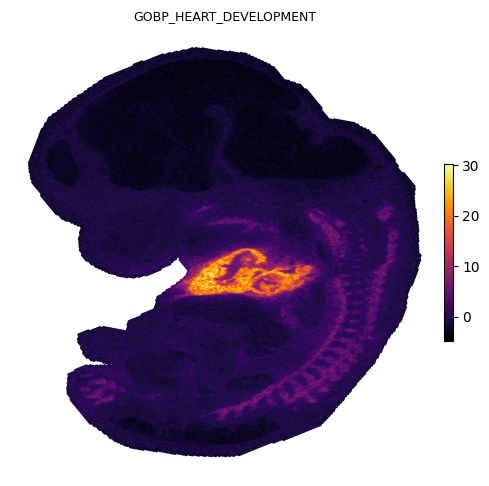

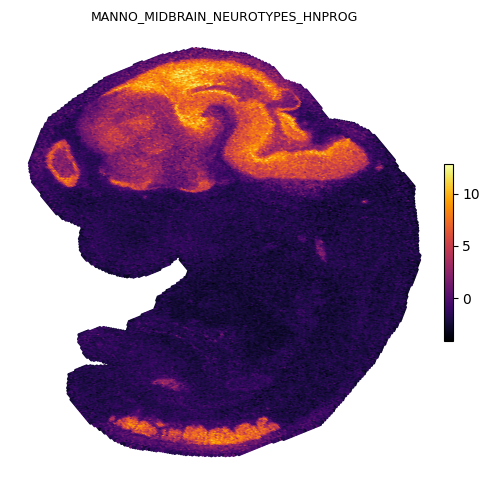

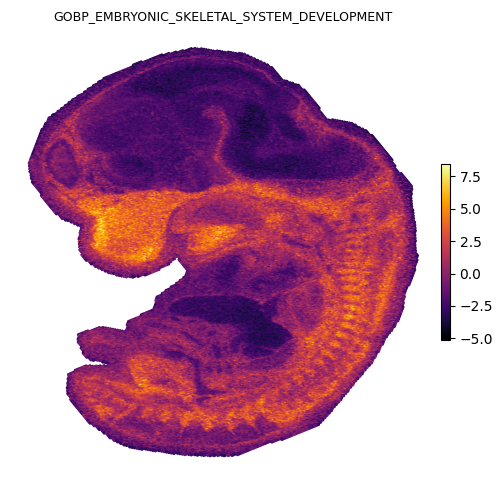

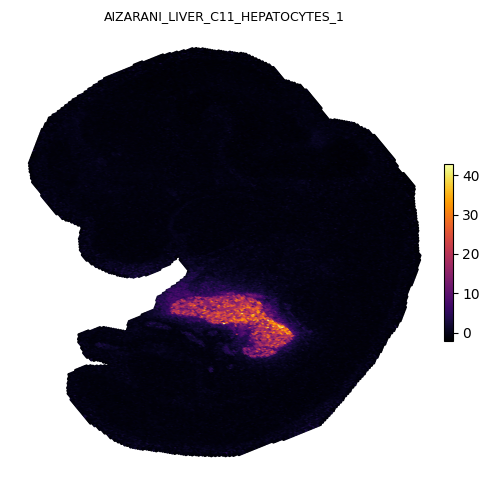

In [9]:
focal_genesets = [
    "GOBP_HEART_DEVELOPMENT",
    "MANNO_MIDBRAIN_NEUROTYPES_HNPROG",
    "GOBP_EMBRYONIC_SKELETAL_SYSTEM_DEVELOPMENT",
    "AIZARANI_LIVER_C11_HEPATOCYTES_1",
]

for geneset in focal_genesets:
    fig = gas_report.plot_gas_spatial_map(
        geneset=geneset,
        size=2,
        cmap="inferno",
        figsize=(5, 5),
    )
    ax = fig.axes[0]
    ax.set_title(geneset, fontsize=9)
    ax.invert_yaxis()  # anatomical orientation
    display(fig)
    plt.close(fig)

### Spatial gradients of GESSO activity scores

GESSO's smoothed activity scores form a scalar field over the tissue. Local spatial gradients $(\partial \text{GAS} / \partial x,\ \partial \text{GAS} / \partial y)$ point from low-activity to high-activity regions and so highlight tissue boundaries. The gradient direction tells us where an organ system is forming, and the gradient magnitude tells us how sharp the boundary is.

For each spot we estimate the gradient by fitting a local plane to its $k$ nearest neighbors (unweighted least squares).

In [10]:
def compute_spatial_gradients(
    coords: np.ndarray, values: np.ndarray, k_neighbors: int = 30, min_neighbors: int = 4
) -> np.ndarray:
    """Estimate (df/dx, df/dy) at each point via local unweighted least squares.

    For each point, fits delta_f ~= grad_x * delta_x + grad_y * delta_y over its k
    nearest neighbors and returns (grad_x, grad_y).
    """
    n_points = coords.shape[0]
    k_query = min(k_neighbors + 1, n_points)
    tree = cKDTree(coords)
    distances, indices = tree.query(coords, k=k_query)

    gradients = np.full((n_points, 2), np.nan, dtype=np.float64)
    for i in range(n_points):
        neighbor_idx = indices[i, 1:]
        neighbor_dist = distances[i, 1:]
        valid = neighbor_dist > 1e-12
        if np.count_nonzero(valid) < min_neighbors:
            continue
        delta_xy = (coords[neighbor_idx] - coords[i])[valid]
        delta_values = (values[neighbor_idx] - values[i])[valid]
        coef, *_ = np.linalg.lstsq(delta_xy, delta_values, rcond=None)
        gradients[i, 0] = coef[0]
        gradients[i, 1] = coef[1]
    return gradients


coords = locations_df[["x", "y"]].to_numpy(dtype=np.float64)
gradient_records: dict[str, pd.DataFrame] = {}
for geneset in focal_genesets:
    values = gas_df[geneset].to_numpy(dtype=np.float64)
    grads = compute_spatial_gradients(coords, values)
    grad_df = locations_df.copy()
    grad_df["score"] = values
    grad_df["grad_x"] = grads[:, 0]
    grad_df["grad_y"] = grads[:, 1]
    grad_df["grad_mag"] = np.sqrt(grad_df["grad_x"] ** 2 + grad_df["grad_y"] ** 2)
    gradient_records[geneset] = grad_df
    print(f"{geneset}: median |grad| = {grad_df['grad_mag'].median():.4f}")

GOBP_HEART_DEVELOPMENT: median |grad| = 0.1476


MANNO_MIDBRAIN_NEUROTYPES_HNPROG: median |grad| = 0.1208


GOBP_EMBRYONIC_SKELETAL_SYSTEM_DEVELOPMENT: median |grad| = 0.2156


AIZARANI_LIVER_C11_HEPATOCYTES_1: median |grad| = 0.0776


We render each gradient field as a heatmap of $|\nabla \text{GAS}|$ overlaid with binned down-gradient arrows. Bins keep only the strongest gradients per gene set (per-gene-set percentile threshold, since each organ has a different signal-to-background ratio). Arrows point down the gradient so they flow away from the highest-activity region.

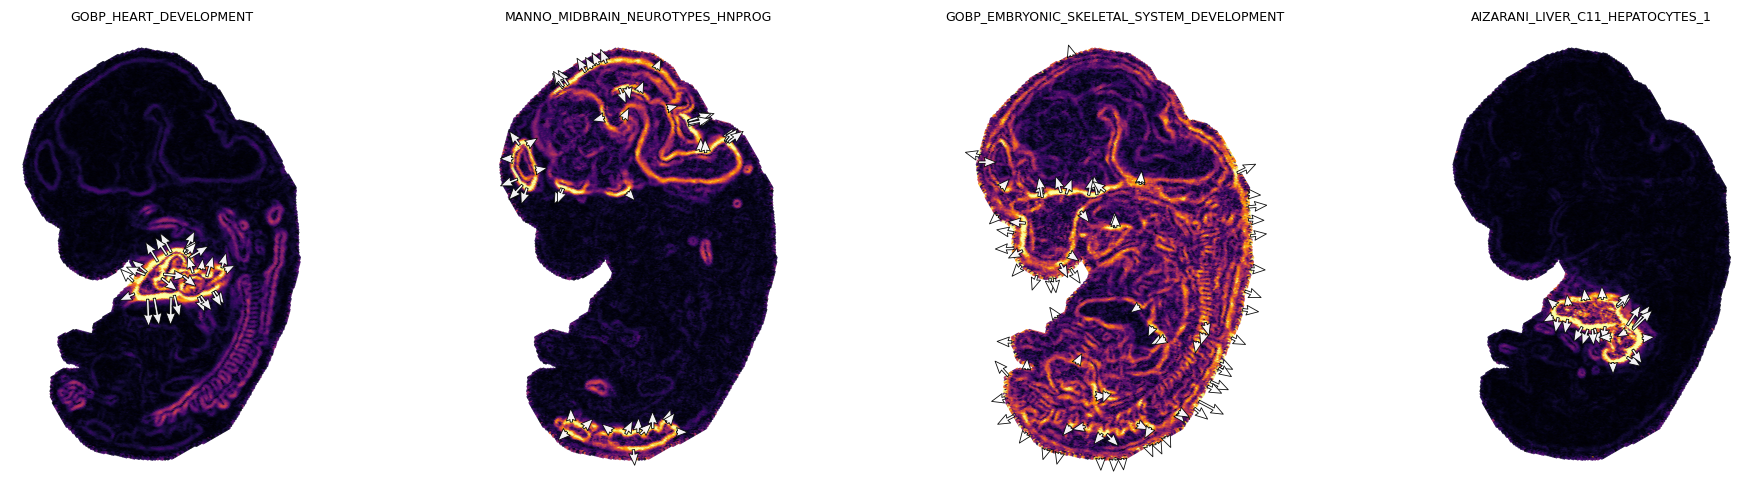

In [ ]:
N_BINS_X = N_BINS_Y = 22
MIN_POINTS_PER_BIN = 6
QUIVER_MAG_PERCENTILE_BY_GENESET = {
    "MANNO_MIDBRAIN_NEUROTYPES_HNPROG": 88,
    "GOBP_HEART_DEVELOPMENT": 93,
    "GOBP_EMBRYONIC_SKELETAL_SYSTEM_DEVELOPMENT": 80,
    "AIZARANI_LIVER_C11_HEPATOCYTES_1": 94,
}
BG_VMAX_PERCENTILE = 99
QUIVER_LENGTH_FRAC = 2.2
QUIVER_LENGTH_FLOOR = 0.4


def bin_strongest_gradient(df: pd.DataFrame, mag_percentile: float):
    x, y = df["x"].to_numpy(float), df["y"].to_numpy(float)
    x_min, x_max, y_min, y_max = x.min(), x.max(), y.min(), y.max()
    x_span, y_span = max(x_max - x_min, 1e-12), max(y_max - y_min, 1e-12)
    bin_pitch = min(x_span / N_BINS_X, y_span / N_BINS_Y)
    df = df.copy()
    df["bin_x"] = np.clip(((x - x_min) / x_span * N_BINS_X).astype(int), 0, N_BINS_X - 1)
    df["bin_y"] = np.clip(((y - y_min) / y_span * N_BINS_Y).astype(int), 0, N_BINS_Y - 1)
    max_idx = df.groupby(["bin_x", "bin_y"], observed=True)["grad_mag"].idxmax()
    tails = df.loc[max_idx, ["bin_x", "bin_y", "x", "y", "grad_x", "grad_y", "grad_mag"]]
    sizes = (
        df.groupby(["bin_x", "bin_y"], observed=True).size()
        .rename("n_points").reset_index()
    )
    g = tails.merge(sizes, on=["bin_x", "bin_y"]).reset_index(drop=True)
    g = g[g["n_points"] >= MIN_POINTS_PER_BIN].copy()
    g["bin_grad_mag"] = np.sqrt(g["grad_x"] ** 2 + g["grad_y"] ** 2)
    if mag_percentile > 0 and len(g) > 0:
        thr = np.percentile(g["bin_grad_mag"], mag_percentile)
        g = g[g["bin_grad_mag"] >= thr].copy()
    return g, bin_pitch


fig, axes = plt.subplots(1, len(focal_genesets), figsize=(5 * len(focal_genesets), 5))
for ax, geneset in zip(axes, focal_genesets):
    df = gradient_records[geneset].dropna(subset=["grad_x", "grad_y"]).copy()
    pct = QUIVER_MAG_PERCENTILE_BY_GENESET.get(geneset, 90)
    quiver_df, bin_pitch = bin_strongest_gradient(df, pct)

    vmin = float(df["grad_mag"].min())
    vmax = float(np.percentile(df["grad_mag"], BG_VMAX_PERCENTILE))
    sns.scatterplot(
        data=df, x="x", y="y", hue="grad_mag", ax=ax, s=4, edgecolor=None, legend=False,
        palette="inferno", alpha=0.85, linewidth=0, hue_norm=(vmin, vmax),
    )
    if not quiver_df.empty:
        mag = quiver_df["bin_grad_mag"].to_numpy()
        mag_safe = np.where(mag > 0, mag, 1.0)
        ux = -quiver_df["grad_x"].to_numpy() / mag_safe  # negate -> down-gradient arrows
        uy = -quiver_df["grad_y"].to_numpy() / mag_safe
        if mag.max() > mag.min():
            weight = QUIVER_LENGTH_FLOOR + (1.0 - QUIVER_LENGTH_FLOOR) * (mag - mag.min()) / (mag.max() - mag.min())
        else:
            weight = np.ones_like(mag)
        L = bin_pitch * QUIVER_LENGTH_FRAC * weight
        ax.quiver(
            quiver_df["x"], quiver_df["y"], ux * L, uy * L,
            color="white", edgecolor="black", linewidth=0.6, alpha=0.95,
            angles="xy", scale_units="xy", scale=1,
            width=0.008, headwidth=4, headlength=5, headaxislength=4.5, zorder=3,
        )
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="both", which="both", length=0, labelbottom=False, labelleft=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(geneset, fontsize=9)
fig.tight_layout()
display(fig)
plt.close(fig)

Each panel shows the local gradient magnitude as a heatmap (bright = sharp boundary) and the strongest down-gradient arrows pointing from low to high activity in reverse i.e. arrows point away from each organ's center. The heart, brain, skeletal, and liver signals each localize to anatomically expected regions of the E12.5 embryo.